## 01 — Implementing Douglas-Peucker

We traced the algorithm by hand. Now we implement it.

The implementation has two parts:

1. `perpendicular_distance(point, start, end)` — the geometric primitive
2. `douglas_peucker(coords, epsilon)` — the recursive algorithm

Then we verify our output against `shapely.simplify()` to confirm correctness.

## Part 1 — Perpendicular Distance

Given a point P and a line segment from A to B, we need the shortest distance from P to the **infinite line** passing through A and B.

The formula comes from the cross product. In 2D:

```
distance = |( B.y - A.y) * P.x  -  (B.x - A.x) * P.y  +  B.x * A.y  -  B.y * A.x|
           ────────────────────────────────────────────────────────────────────────────
                               sqrt( (B.x - A.x)² + (B.y - A.y)² )
```

The numerator is the absolute area of the parallelogram formed by vectors AB and AP. Dividing by |AB| gives the height — the perpendicular distance.

In [1]:
import math

def perpendicular_distance(point, start, end):
    """Return the perpendicular distance from `point` to the line through `start` and `end`."""
    px, py = point
    ax, ay = start
    bx, by = end

    dx = bx - ax
    dy = by - ay

    # Degenerate case: start and end are the same point
    if dx == 0 and dy == 0:
        return math.sqrt((px - ax) ** 2 + (py - ay) ** 2)

    numerator = abs(dy * px - dx * py + bx * ay - by * ax)
    denominator = math.sqrt(dx ** 2 + dy ** 2)
    return numerator / denominator

Let's verify with a case we can check by inspection.

If the line runs along y = 0 (from (0,0) to (10,0)), then the perpendicular distance from a point (5, 3) should be exactly 3.

In [2]:
dist = perpendicular_distance((5, 3), (0, 0), (10, 0))
print(f"Distance from (5, 3) to line y=0: {dist}")   # expected: 3.0

dist2 = perpendicular_distance((5, 0), (0, 0), (10, 0))
print(f"Distance from (5, 0) to line y=0: {dist2}")  # expected: 0.0 (on the line)

Distance from (5, 3) to line y=0: 3.0
Distance from (5, 0) to line y=0: 0.0


## Part 2 — The Recursive Algorithm

In [3]:
def douglas_peucker(coords, epsilon):
    """
    Simplify a list of (x, y) coordinate pairs using the Douglas-Peucker algorithm.
    Returns a new list containing only the points that survive the tolerance threshold.
    """
    if len(coords) < 3:
        return list(coords)

    start = coords[0]
    end   = coords[-1]

    # Find the interior point with maximum perpendicular distance
    max_dist = 0.0
    max_idx  = 0

    for i in range(1, len(coords) - 1):
        dist = perpendicular_distance(coords[i], start, end)
        if dist > max_dist:
            max_dist = dist
            max_idx  = i

    if max_dist > epsilon:
        # Real bend — keep that point, recurse on both halves
        left  = douglas_peucker(coords[:max_idx + 1], epsilon)
        right = douglas_peucker(coords[max_idx:],     epsilon)
        # Combine: left ends with the pivot, right starts with it — drop the duplicate
        return left[:-1] + right
    else:
        # Flat enough — discard all interior points
        return [start, end]

## Testing on a Known Example

Let's test with the same 7-point line from the previous notebook, and confirm the output matches what we traced by hand.

In [4]:
points = [
    (0, 0),
    (1, 0.1),
    (2, 0.5),
    (3, 0.2),
    (4, 0.15),
    (5, 0.1),
    (6, 0),
]

result = douglas_peucker(points, epsilon=0.3)

print("Original:",   len(points), "points")
print("Simplified:", len(result), "points")
print("Kept:", result)
print()
print("Expected: [(0,0), (2,0.5), (6,0)]")

Original: 7 points
Simplified: 3 points
Kept: [(0, 0), (2, 0.5), (6, 0)]

Expected: [(0,0), (2,0.5), (6,0)]


## Testing at Multiple Epsilon Values

Same line, different thresholds.

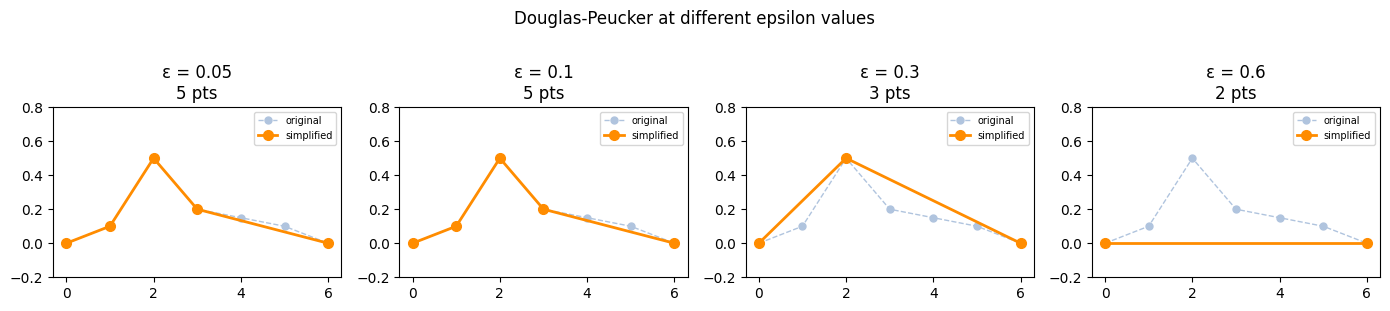

In [5]:
import matplotlib.pyplot as plt

epsilons = [0.05, 0.1, 0.3, 0.6]

fig, axes = plt.subplots(1, len(epsilons), figsize=(14, 3))

for ax, eps in zip(axes, epsilons):
    simplified = douglas_peucker(points, epsilon=eps)
    xs_s = [p[0] for p in simplified]
    ys_s = [p[1] for p in simplified]
    xs_o = [p[0] for p in points]
    ys_o = [p[1] for p in points]

    ax.plot(xs_o, ys_o, 'o--', color='lightsteelblue', linewidth=1, markersize=5, label='original')
    ax.plot(xs_s, ys_s, 'o-',  color='darkorange',     linewidth=2, markersize=7, label='simplified')
    ax.set_title(f'ε = {eps}\n{len(simplified)} pts')
    ax.set_ylim(-0.2, 0.8)
    ax.legend(fontsize=7)

plt.suptitle('Douglas-Peucker at different epsilon values', y=1.02)
plt.tight_layout()
plt.show()

## Verifying Against Shapely

Shapely's `simplify()` method also implements Douglas-Peucker (with `preserve_topology=False`). Let's compare outputs on a longer generated line.

In [6]:
%pip install shapely

Note: you may need to restart the kernel to use updated packages.


In [7]:
import math
from shapely.geometry import LineString

# Generate a wavy line with 50 points
wavy = [(i * 0.2, math.sin(i * 0.5) + math.sin(i * 1.3) * 0.3) for i in range(50)]

epsilon = 0.2

# Our implementation
our_result = douglas_peucker(wavy, epsilon)

# Shapely's implementation
shapely_line = LineString(wavy)
shapely_result = list(shapely_line.simplify(epsilon, preserve_topology=False).coords)

print(f"Original:         {len(wavy)} points")
print(f"Our result:       {len(our_result)} points")
print(f"Shapely result:   {len(shapely_result)} points")

Original:         50 points
Our result:       14 points
Shapely result:   14 points


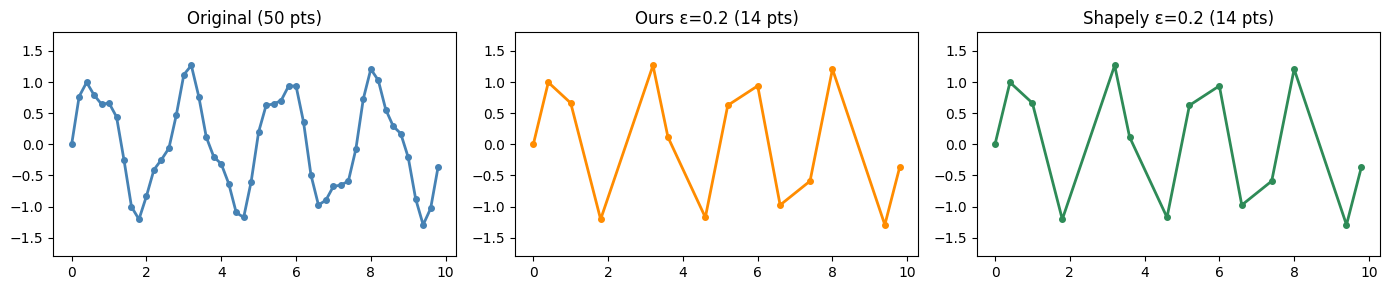

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, pts, title, color in [
    (axes[0], wavy,           f'Original ({len(wavy)} pts)',              'steelblue'),
    (axes[1], our_result,     f'Ours ε={epsilon} ({len(our_result)} pts)',     'darkorange'),
    (axes[2], shapely_result, f'Shapely ε={epsilon} ({len(shapely_result)} pts)', 'seagreen'),
]:
    xs_ = [p[0] for p in pts]
    ys_ = [p[1] for p in pts]
    ax.plot(xs_, ys_, 'o-', color=color, linewidth=2, markersize=4)
    ax.set_title(title)
    ax.set_ylim(-1.8, 1.8)

plt.tight_layout()
plt.show()

The point counts should be very close or identical. Minor differences can occur due to floating-point tie-breaking in edge cases — this is normal.

The key test is visual: both simplified lines should look like the same shape.

## Exercise A

Add a print statement inside `douglas_peucker` that outputs a message each time it recurses. Run it on the 7-point example with `epsilon=0.3`.

How many recursive calls are made? Does the count match what you traced by hand in the previous notebook?

In [9]:
# Copy douglas_peucker here and add a print statement to count recursive calls

call_counter = {"total": 0}

def douglas_peucker_traced(coords, epsilon, depth=0):
    """
    Same Douglas-Peucker algorithm, but prints each function call so we can
    count the recursion tree.
    """
    call_counter["total"] += 1
    indent = "  " * depth
    print(f"{indent}call {call_counter['total']}: {len(coords)} points")

    if len(coords) < 3:
        print(f"{indent}base case: fewer than 3 points")
        return list(coords)

    start = coords[0]
    end = coords[-1]

    max_dist = 0.0
    max_idx = 0

    for i in range(1, len(coords) - 1):
        dist = perpendicular_distance(coords[i], start, end)
        if dist > max_dist:
            max_dist = dist
            max_idx = i

    print(f"{indent}max distance = {max_dist:.3f} at index {max_idx}")

    if max_dist > epsilon:
        print(f"{indent}recurse because {max_dist:.3f} > {epsilon}")
        left = douglas_peucker_traced(coords[:max_idx + 1], epsilon, depth + 1)
        right = douglas_peucker_traced(coords[max_idx:], epsilon, depth + 1)
        return left[:-1] + right
    else:
        print(f"{indent}stop because {max_dist:.3f} <= {epsilon}")
        return [start, end]

call_counter["total"] = 0
traced_result = douglas_peucker_traced(points, epsilon=0.3)

print("\nSimplified result:", traced_result)
print("Total function calls including the first call:", call_counter["total"])
print("Recursive calls after the first call:", call_counter["total"] - 1)
print("This matches the hand trace: the first call splits once into two sub-problems.")


call 1: 7 points
max distance = 0.500 at index 2
recurse because 0.500 > 0.3
  call 2: 3 points
  max distance = 0.146 at index 1
  stop because 0.146 <= 0.3
  call 3: 5 points
  max distance = 0.174 at index 1
  stop because 0.174 <= 0.3

Simplified result: [(0, 0), (2, 0.5), (6, 0)]
Total function calls including the first call: 3
Recursive calls after the first call: 2
This matches the hand trace: the first call splits once into two sub-problems.


## Exercise B

The current implementation works on `(x, y)` tuples. GeoJSON coordinates are stored as `[lon, lat]` lists.

Modify `douglas_peucker` (or write a wrapper) so it accepts GeoJSON-style `[lon, lat]` lists and returns the same format. Test it on a short hand-written list of coordinates.

In [10]:
# Adapt douglas_peucker to accept and return [lon, lat] lists
# Test with a short example

def douglas_peucker_geojson(coords, epsilon):
    """
    Wrapper for GeoJSON-style coordinates.
    Input:  [[lon, lat], [lon, lat], ...]
    Output: [[lon, lat], [lon, lat], ...]
    """
    tuple_coords = [tuple(c) for c in coords]
    simplified_tuples = douglas_peucker(tuple_coords, epsilon)
    return [[lon, lat] for lon, lat in simplified_tuples]

geojson_coords = [
    [0, 0],
    [1, 0.05],
    [2, 0.8],
    [3, 0.04],
    [4, 0],
]

simplified_geojson = douglas_peucker_geojson(geojson_coords, epsilon=0.1)

print("Original GeoJSON-style coordinates:")
print(geojson_coords)
print("\nSimplified GeoJSON-style coordinates:")
print(simplified_geojson)
print("\nOutput type check:", type(simplified_geojson[0]).__name__)


Original GeoJSON-style coordinates:
[[0, 0], [1, 0.05], [2, 0.8], [3, 0.04], [4, 0]]

Simplified GeoJSON-style coordinates:
[[0, 0], [1, 0.05], [2, 0.8], [3, 0.04], [4, 0]]

Output type check: list


## Check Your Understanding

The `douglas_peucker` function is recursive. For a line with `n` points, what is the **worst-case** number of recursive calls — and what shape of input would produce it?

Hint: think about what happens when every interior point has a distance just above epsilon.

Write your answer as a comment.

---

### Check Your Understanding — Answer

In the worst case, Douglas-Peucker makes a linear number of function calls: up to about `2n - 3` total calls if the first call is included, or `2n - 4` recursive calls after the first call. This happens when every interior point must be kept, so the recursion keeps splitting until the line is reduced to 2-point base cases. The slowest shape is an unbalanced one where the farthest point is always near one endpoint; that still gives `O(n)` calls, but the repeated scans make the total running time `O(n²)`.

## Next

In [02 — Epsilon and Tradeoffs](./02-Epsilon_and_Tradeoffs.ipynb), we apply the algorithm to real railroad data and see what different epsilon values look like on an actual map.